# K-means Segmentación de clientes de clustering

En este proyecto, realizaremos agrupaciones de K-means para segmentar a los clientes en función de su comportamiento de compra. El objetivo es identificar distintos grupos de clientes a los que se puede dirigir estrategias de marketing específicas.

Usaremos un análisis RFM (recencia, frecuencia, monetario) para crear funciones para la agrupación.

El objetivo de este proyecto es:
- Comprender el comportamiento de compra de los clientes.
- Comparar diferentes segmentos entre enfoques basados ​​en datos y enfoques basados ​​en negocios.
- Analizar las características de cada segmento de clientes para informar las estrategias de marketing.

### Objetivos adicionales y alcance analítico

- **Validación técnica y optimización:**
    - Evaluar la calidad, cohesión y separación de los conglomerados utilizando métricas matemáticas como la **Puntuación de silueta**, el **Método del codo** y el **Índice Davies-Bouldin** para justificar el número óptimo de conglomerados.
    - Implementar técnicas sólidas de preprocesamiento de datos, incluido el manejo de valores atípicos (especialmente valores *monetarios* sesgados) y transformaciones logarítmicas o escalado de características para evitar la distorsión del centroide.

- **Estrategia empresarial e impacto financiero:**
    - Diseñar estrategias de marketing de ciclo de vida, adquisición y retención personalizadas para cada segmento de clientes distinto (por ejemplo, campañas de reactivación para clientes "en riesgo" frente a programas de fidelización para "campeones").
    - Calcule el retorno financiero potencial y el **Valor de vida del cliente (CLV)** asociado con cada grupo para ayudar a priorizar la asignación del presupuesto de marketing.

In [185]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


customers = pd.read_csv("../../data/processed/prepared_customers.csv")

customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 4335 entries, 0 to 4334
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      4335 non-null   int64  
 1   recency          4335 non-null   int64  
 2   frequency        4335 non-null   int64  
 3   monetary         4335 non-null   float64
 4   avg_order_value  4335 non-null   float64
 5   avg_quantity     4335 non-null   float64
 6   discount_rate    4335 non-null   float64
dtypes: float64(4), int64(3)
memory usage: 237.2 KB


## K-medias con valores atípicos

En esta parte del análisis, intentaremos explorar las K-medias con escalado estándar y transformación logarítmica para ver cómo se forman los grupos con valores atípicos presentes en los datos. También visualizaremos los clusters para entender sus características.

In [186]:
X = customers[["recency", "frequency", "monetary" , "avg_order_value" , "avg_quantity" , "discount_rate"]].copy()
X_log = np.log1p(X)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_log)


## Método del codo

Para saber cuál es el número óptimo de clusters, usaremos el método del codo. El método del codo implica trazar la variación explicada en función del número de conglomerados y seleccionar el codo de la curva como el número de conglomerados a utilizar.

In [187]:
inertias = []
silhouette_scores = []

K = range(2, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_scaled, labels)

    inertias.append(inertia)
    silhouette_scores.append(silhouette)

    print(
        f"K={k} | "
        f"Inertia={inertia:.2f} | "
        f"Silhouette={silhouette:.4f}"
    )

K=2 | Inertia=19287.56 | Silhouette=0.3161
K=3 | Inertia=15665.01 | Silhouette=0.3163
K=4 | Inertia=12509.54 | Silhouette=0.3204
K=5 | Inertia=10846.71 | Silhouette=0.2690
K=6 | Inertia=9614.70 | Silhouette=0.2404
K=7 | Inertia=8863.53 | Silhouette=0.2273
K=8 | Inertia=8194.58 | Silhouette=0.2305
K=9 | Inertia=7637.97 | Silhouette=0.2377
K=10 | Inertia=7137.85 | Silhouette=0.2370


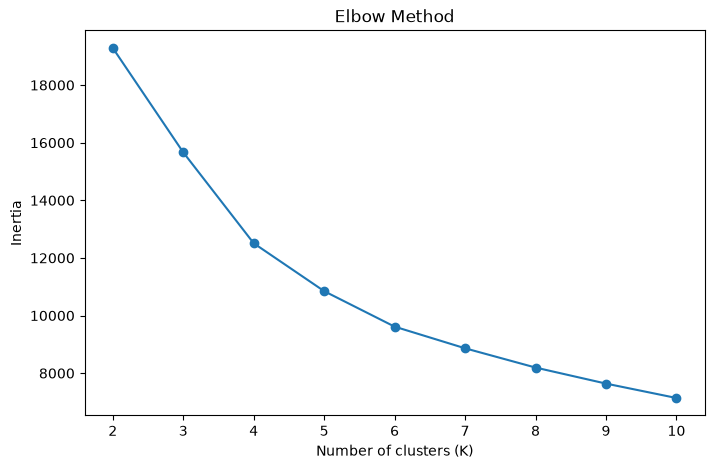

In [188]:
plt.figure(figsize=(8, 5))

plt.plot(K, inertias, marker='o')

plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")


plt.show()

## Resumen

Usaremos K=4 porque tiene la **puntuación de silueta más alta (0,3204)**, lo que indica que proporciona la mejor separación de grupos entre los valores evaluados de K. Además, el método del codo muestra una disminución significativa en la inercia hasta K=4. Después de eso, la reducción de la inercia se vuelve menos pronunciada, lo que sugiere que agregar más conglomerados proporciona rendimientos decrecientes.

Por lo tanto, usaremos K=4 para crear los clusters y analizar las características de cada segmento. Luego evaluaremos si es posible desarrollar una estrategia de negocio específica para cada cluster y estimaremos su potencial impacto financiero en la empresa.

In [189]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customers['cluster'] = kmeans.fit_predict(X_scaled)
customers['cluster'] = customers['cluster'].astype('category')

customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 4335 entries, 0 to 4334
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   customer_id      4335 non-null   int64   
 1   recency          4335 non-null   int64   
 2   frequency        4335 non-null   int64   
 3   monetary         4335 non-null   float64 
 4   avg_order_value  4335 non-null   float64 
 5   avg_quantity     4335 non-null   float64 
 6   discount_rate    4335 non-null   float64 
 7   cluster          4335 non-null   category
dtypes: category(1), float64(4), int64(3)
memory usage: 241.4 KB


## Resumen

Aplicamos agrupación de K-medias y creamos una nueva columna en el conjunto de datos llamada`cluster`para almacenar las etiquetas de agrupación para cada cliente. Los grupos se representan como valores categóricos, lo que permite un fácil análisis e interpretación de los segmentos de clientes.

Esta columna nos ayuda a analizar las características de cada grupo y desarrollar estrategias de marketing específicas para cada segmento.

In [190]:
customers["cluster"].value_counts().sort_index()

cluster
0    1490
1     399
2    2444
3       2
Name: count, dtype: int64

Encontramos un problema, el cluster 4 solo tiene 2 clientes, esto significa que el cluster no es representativo de la población y necesitamos reevaluar la cantidad de clusters. Intentaremos usar K=3 y veremos si podemos obtener mejores resultados.

In [191]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customers["cluster"] = kmeans.fit_predict(X_scaled)

customers["cluster"].value_counts().sort_index()

cluster
0    1600
1    2733
2       2
Name: count, dtype: int64

In [192]:
customers[customers["cluster"] == 2]

,customer_id,recency,frequency,monetary,avg_order_value,avg_quantity,discount_rate,cluster
2168,15299,66,7,3907.01,558.144286,420.857143,0.142857,2
4084,17940,48,11,2152.18,113.272632,490.526316,0.105263,2


Encontramos el problema de que tienen una gran cantidad de avg_quantity y avg_order_value, esto significa que no son representativos de la población y necesitamos reevaluar la cantidad de conglomerados.

Segmentaremos a estos clientes como **"Compradores de gran volumen"** y analizaremos su comportamiento de compra por separado. Esto nos ayudará a comprender si requieren un enfoque de marketing diferente al de los otros grupos.

In [193]:
special_customers = [15299, 17940]

customers_normal = customers[
    ~customers["customer_id"].isin(special_customers)
].copy()

customers_normal = customers_normal.drop(columns=["cluster"], errors="ignore")

In [194]:
X = customers_normal[
    [
        "recency",
        "frequency",
        "monetary",
        "avg_order_value",
        "avg_quantity",
        "discount_rate"
    ]
]

X_log = np.log1p(X)

X_scaled = StandardScaler().fit_transform(X_log)

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customers_normal["cluster"] = kmeans.fit_predict(X_scaled)
customers_normal.value_counts("cluster").sort_index()

cluster
0     406
1    2434
2    1487
3       6
Name: count, dtype: int64

In [195]:
customers_normal[customers_normal["cluster"] == 3]

,customer_id,recency,frequency,monetary,avg_order_value,avg_quantity,discount_rate,cluster
381,12830,37,7,6814.64,174.734359,252.487179,0.025641,3
795,13408,1,66,28117.04,57.973278,33.453608,0.014433,3
1602,14527,2,83,8506.13,8.463811,2.040796,0.034826,3
1880,14912,16,3,867.85,30.994643,34.642857,0.035714,3
2701,16029,38,68,72708.09,295.561341,162.821138,0.024390,3
4244,18167,3,4,1384.86,36.443684,10.026316,0.026316,3


## Resumen del proceso de agrupación de K-means

Tenemos problemas con los valores atípicos en la agrupación, por lo que debemos eliminarlos y volver a ejecutar el proceso de agrupación. Usaremos los siguientes pasos:
1. Identifique los valores atípicos en el conjunto de datos.
2. Elimine los valores atípicos del conjunto de datos.
3. Vuelva a ejecutar el proceso de agrupación en clústeres de K-means con el conjunto de datos limpio.
4. Analizar las características de cada cluster y desarrollar estrategias de marketing específicas para cada segmento.

## K-medias sin valores atípicos

Analizaremos el mismo proceso que hicimos antes, pero ahora eliminaremos los valores atípicos y veremos si podemos obtener mejores resultados. Volveremos a analizar el método del codo y la puntuación de la silueta para ver si podemos obtener mejores resultados. También visualizaremos los clusters para entender sus características.

In [196]:
features = [
    "recency",
    "frequency",
    "monetary",
    "avg_order_value",
    "avg_quantity",
    "discount_rate"
]

X = customers[features].copy()

for col in features:
    lower = X[col].quantile(0.01)
    upper = X[col].quantile(0.99)
    X[col] = X[col].clip(lower, upper)

X_log = np.log1p(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

## Método del codo sin valores atípicos

In [197]:
inertias = []
silhouette_scores = []

K = range(2, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_scaled, labels)

    inertias.append(inertia)
    silhouette_scores.append(silhouette)

    print(
        f"K={k} | "
        f"Inertia={inertia:.2f} | "
        f"Silhouette={silhouette:.4f}"
    )

K=2 | Inertia=14791.00 | Silhouette=0.3118
K=3 | Inertia=11531.00 | Silhouette=0.3191
K=4 | Inertia=9749.66 | Silhouette=0.2783
K=5 | Inertia=8536.73 | Silhouette=0.2464
K=6 | Inertia=7772.29 | Silhouette=0.2470
K=7 | Inertia=7120.74 | Silhouette=0.2435
K=8 | Inertia=6520.54 | Silhouette=0.2454
K=9 | Inertia=6106.03 | Silhouette=0.2235
K=10 | Inertia=5766.34 | Silhouette=0.2216


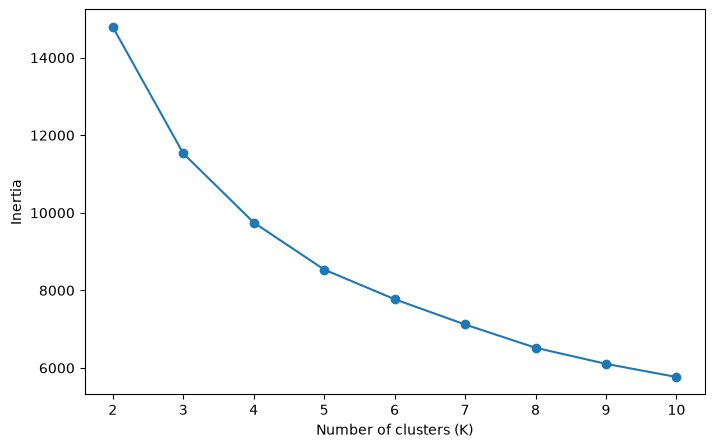

In [198]:
plt.figure(figsize=(8, 5))
plt.plot(K, inertias, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.show()

## Resumen

Aplicamos el método del codo con puntuación de silueta para encontrar el número óptimo de grupos. Descubrimos que K=3 es el mejor número de conglomerados para este conjunto de datos, ya que tiene la puntuación de silueta más alta y el método del codo muestra una disminución significativa en la inercia hasta K=3.

In [199]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customers["cluster"] = kmeans.fit_predict(X_scaled)
customers["cluster"].value_counts().sort_index()

cluster
0    1494
1     471
2    2370
Name: count, dtype: int64

Descubrimos que tenemos tres grupos y analizaremos las características de cada grupo para desarrollar estrategias de marketing específicas para cada segmento.

- **Clúster 0**: Tenemos 1494 clientes en este grupo
- **Clúster 1**: Tenemos 471 clientes en este grupo
- **Clúster 2**: Tenemos 2370 clientes en este grupo

In [200]:
cluster_profile = customers.groupby("cluster")[
    [
        "recency",
        "frequency",
        "monetary",
        "avg_order_value",
        "avg_quantity",
        "discount_rate"
    ]
].mean()

cluster_profile

,recency,frequency,monetary,avg_order_value,avg_quantity,discount_rate
cluster,,,,,,
0,22.463855,8.234270,3204.327711,19.220378,10.918118,0.000072
1,98.554140,4.813163,6201.228514,479.734454,338.528632,0.000824
2,130.078059,1.649367,434.324224,16.819840,9.331057,0.000000


In [201]:
cluster_profile["customer_count"] = customers["cluster"].value_counts()
cluster_profile["customer_percentage"] = (
    cluster_profile["customer_count"] / len(customers) * 100
)

cluster_profile

,recency,frequency,monetary,avg_order_value,avg_quantity,discount_rate,customer_count,customer_percentage
cluster,,,,,,,,
0,22.463855,8.234270,3204.327711,19.220378,10.918118,0.000072,1494,34.463668
1,98.554140,4.813163,6201.228514,479.734454,338.528632,0.000824,471,10.865052
2,130.078059,1.649367,434.324224,16.819840,9.331057,0.000000,2370,54.671280


## Análisis de conglomerados

- **Grupo 0 (Campeones):**
    - Alta frecuencia y valor monetario, lo que indica clientes leales y valiosos.
    - Estrategia de marketing: centrarse en estrategias de retención, programas de fidelización y ofertas exclusivas para mantener el compromiso.

- **Grupo 1 (Gigantes durmientes):**
    - Baja frecuencia y valor monetario, lo que indica clientes que no han interactuado recientemente.
    - Estrategia de marketing: implementar campañas de re-engagement, ofertas personalizadas y recordatorios para fomentar la actividad.

- **Grupo 2 (Clientes de bajo valor / Inactivos):**
    - Baja frecuencia y valor monetario, lo que indica clientes que no están comprando activamente.
    - Estrategia de marketing: considere estrategias de marketing rentables, como campañas de correo electrónico o participación en las redes sociales, para aumentar el conocimiento y el interés.

In [ ]:
customers["cluster_name"] = customers["cluster"].map({
    0: "Champions",
    1: "Sleeping Giants",
    2: "Low Value Customers",
})

customers["cluster_name"].value_counts().sort_index()
customers.drop(columns=["cluster"], inplace=True)
customers.to_csv("../../data/processed/customers_with_clusters.csv", index=False)

# Segmentación de clientes K-Means: Conclusión

## Hallazgos principales

El análisis K-Means agrupó a los clientes según seis variables de comportamiento: actualidad, frecuencia, valor monetario, valor promedio de los pedidos, cantidad promedio y tasa de descuento. Debido a que estas variables estaban fuertemente sesgadas y afectadas por clientes extremos, el análisis aplicó transformación logarítmica y estandarización antes de la agrupación.

El modelo inicial con **K = 4** produjo un grupo que contenía solo dos clientes con una cantidad promedio y un valor promedio de pedido excepcionalmente altos. Este resultado mostró que los valores atípicos podrían distorsionar los centroides y crear un segmento que no era representativo de la base de clientes. Después de controlar los valores extremos mediante recorte de percentiles, transformación logarítmica y escalamiento, **K = 3** proporcionó la solución más útil según el método Elbow y Silhouette Score.

La segmentación final contiene **4.335 clientes**:

| Clúster | Clientes | Compartir | Interpretación empresarial |
| --- | ---: | ---: | --- |
| Grupo 0 | 1.494 | 34,5% | **Campeones**: alta frecuencia y alto valor monetario |
| Grupo 1 | 471 | 10,9% | **Gigantes Durmientes**: compromiso reciente más débil y potencial de reactivación |
| Grupo 2 | 2.370 | 54,7% | **Clientes de bajo valor**: menor frecuencia y valor monetario |

## Interpretación empresarial

- **Los campeones** son el grupo más valioso porque compran con frecuencia y generan mayores ingresos. La prioridad debe ser la retención a través de programas de fidelización, beneficios exclusivos, recomendaciones personalizadas y acceso temprano a los productos.
- **Gigantes Durmientes** representan una oportunidad para recuperar el compromiso anterior. Se deben probar campañas personalizadas de recuperación, recomendaciones de productos relevantes e incentivos limitados antes de que estos clientes se vuelvan inactivos.
- Los **Clientes de bajo valor** son el grupo más grande. Se pueden utilizar una comunicación amplia y de bajo costo, educación sobre el producto, ventas cruzadas y promociones cuidadosamente dirigidas para aumentar la frecuencia de compra y el valor promedio de los pedidos sin un costo excesivo de marketing.
- Los dos clientes excepcionales de alto volumen identificados durante el primer intento de agrupación deben monitorearse por separado. Su comportamiento puede reflejar compras al por mayor o patrones de pedidos inusuales y no debería definir el comportamiento de una base de clientes más amplia.

## Conclusión general

El análisis confirma que los clientes no tienen un comportamiento de compra uniforme, por lo que una única estrategia de marketing no sería eficiente. La solución de tres clústeres proporciona un marco práctico para priorizar las actividades de retención, reactivación y desarrollo de clientes. Proteger a los campeones es esencial porque el comportamiento de alto valor se concentra en una parte relativamente pequeña de la base de clientes, mientras que el gran grupo de clientes de bajo valor ofrece la mayor oportunidad de crecimiento futuro.

Estos grupos deben tratarse como perfiles de comportamiento en lugar de categorías permanentes de clientes. Describen patrones de compra históricos y no predicen directamente la deserción o los ingresos futuros. Por lo tanto, el modelo debe actualizarse periódicamente y evaluarse utilizando el comportamiento de compra futuro, la respuesta de la campaña, los ingresos, el margen y el valor de vida del cliente.